# Barter analysis: interesting metrics

# Comments

## General comments

- 12th of January: release of Feed V3. Clearly visible in the data. 

## Ideas

- Creators per deal/company
    - We see the number of active creators go down, does that also mean that the number of creators per deal go down?
    - Need to compute nr of active deals
- Number of active high-value creators

- Timeline of active partners/ creators over time (bar chart race)
- Proportion of eligible users that applied
    - ratio="eligible in first week of deal" / apps after 7 days
    - Use this to track "market competitiveness":
        - Check if ratio increases or decreases over time 
        - Ratio indicates whether "deals are (un)attractive" (and to a smaller extent, "there are too many deals")
            - If the ratio is high, that means that many active users are not applying 
        - Need a method to control for outliers (the mean ratio could be affected by high-ratio deals)


# Init

In [20]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text

import numpy as np
import pandas as pd
from collections import defaultdict

# from src.utils import interactive_dataframe_selector

# Local files

In [21]:
from src import paths
df_apps = pd.read_parquet(paths.RAW_DATA_DIR / 'BARTER_DEAL_APPLICATIONS.parquet')
# df_apps = df_apps.rename(columns={'address_name': 'city_creator'})

In [22]:
df_apps

,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,...,email_address_partners,registered_at_partners,subscription_status_partners,subscription_start_date_partners,subscription_end_date_partners,deals_count_partners,live_deals_count_partners,locations_count_partners,company_size_partners,worked_with_creators_partners
0,335,019689e3-9b82-00c8-52df-2e22979a06ee,8162,<NA>,2024-04-12 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,haleigh.feest@anonymized.getbarter.com,2024-02-15 14:31:26.387130+00:00,active,2024-02-15 14:31:21+00:00,2026-03-16 14:31:21+00:00,2.0,0.0,2.0,<NA>,<NA>
1,335,019689e3-9b82-00c8-52df-2e22979a06ee,7787,<NA>,2024-03-26 00:00:00+00:00,cancelled,NaT,<NA>,NaN,<NA>,...,haleigh.feest@anonymized.getbarter.com,2024-02-15 14:31:26.387130+00:00,active,2024-02-15 14:31:21+00:00,2026-03-16 14:31:21+00:00,2.0,0.0,2.0,<NA>,<NA>
2,335,019689e3-9b82-00c8-52df-2e22979a06ee,7827,<NA>,2024-05-29 00:00:00+00:00,accepted,NaT,<NA>,NaN,<NA>,...,haleigh.feest@anonymized.getbarter.com,2024-02-15 14:31:26.387130+00:00,active,2024-02-15 14:31:21+00:00,2026-03-16 14:31:21+00:00,2.0,0.0,2.0,<NA>,<NA>
3,335,019689e3-9b82-00c8-52df-2e22979a06ee,358,<NA>,2024-07-19 00:00:00+00:00,accepted,NaT,<NA>,NaN,<NA>,...,haleigh.feest@anonymized.getbarter.com,2024-02-15 14:31:26.387130+00:00,active,2024-02-15 14:31:21+00:00,2026-03-16 14:31:21+00:00,2.0,0.0,2.0,<NA>,<NA>
4,335,019689e3-9b82-00c8-52df-2e22979a06ee,343,<NA>,2024-05-20 00:00:00+00:00,accepted,NaT,<NA>,NaN,<NA>,...,haleigh.feest@anonymized.getbarter.com,2024-02-15 14:31:26.387130+00:00,active,2024-02-15 14:31:21+00:00,2026-03-16 14:31:21+00:00,2.0,0.0,2.0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269729,102,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,<NA>,2024-06-29 00:00:00+00:00,finished,NaT,<NA>,NaN,<NA>,...,marlene@anonymized.getbarter.com,2023-10-06 14:09:42.860289+00:00,active,2026-02-17 11:16:02+00:00,2027-02-17 11:31:14+00:00,4.0,1.0,1.0,<NA>,<NA>
269730,102,019689e4-4bc6-00c8-6ff0-06aca342b058,1577,<NA>,2024-07-06 00:00:00+00:00,finished,NaT,<NA>,NaN,<NA>,...,marlene@anonymized.getbarter.com,2023-10-06 14:09:42.860289+00:00,active,2026-02-17 11:16:02+00:00,2027-02-17 11:31:14+00:00,4.0,1.0,1.0,<NA>,<NA>
269731,<NA>,019b359e-7880-00c8-ba13-e73e44044ea9,36953,<NA>,2025-12-22 23:00:00+00:00,accepted,NaT,<NA>,NaN,<NA>,...,watsica.jaiden@anonymized.getbarter.com,2025-12-04 15:26:35.524300+00:00,active,2025-12-19 08:01:56+00:00,2026-03-24 18:39:37+00:00,2.0,1.0,1.0,xs,True
269732,<NA>,019b6abb-9953-00c8-168a-f649e05f64ba,34252,<NA>,NaT,accepted,NaT,<NA>,NaN,<NA>,...,watsica.jaiden@anonymized.getbarter.com,2025-12-04 15:26:35.524300+00:00,active,2025-12-19 08:01:56+00:00,2026-03-24 18:39:37+00:00,2.0,1.0,1.0,xs,True


In [23]:
df_apps.loc[df_apps.reviews_count_creators == 0,'rating_creators'] = pd.NA
df_apps['rating_creators'] = df_apps['rating_creators'].round(0)


# Define the edges of your buckets
# Note: -1 is used as the start to ensure 0 is included in the first bucket
bins = [-1, 0, 5, 10, 15, 20, 30, 40]

# Define the labels for the buckets
labels = ['0', '1-5', '6-10', '11-15', '16-20', '21-30', '31-40']

df_apps['reviews_bucket'] = pd.cut(
    df_apps['reviews_count_creators'], 
    bins=bins, 
    labels=labels
)

In [24]:
df_apps.country_code_company_locations.value_counts()

country_code_company_locations
NL    166842
BE      7950
GB      3580
DE       475
         359
ES       258
AD        77
AT        61
ID        50
US        30
MT         3
CI         2
IE         2
ZA         2
PT         1
SE         1
TD         1
Name: count, dtype: Int64

In [25]:
# df_apps.loc[df_apps.country_company_locations == 'Nederland', 'country_company_locations'] = "Netherlands"
# df_apps.loc[df_apps.country_company_locations == 'Hollanda', 'country_company_locations'] = "Netherlands"
# df_apps.loc[df_apps.country_company_locations == '荷兰', 'country_company_locations'] = "Netherlands"
# df_apps.loc[df_apps.country_company_locations == '荷蘭', 'country_company_locations'] = "Netherlands"
# df_apps.loc[df_apps.country_company_locations == 'เนเธอร์แลนด์', 'country_company_locations'] = "Netherlands"


# df_apps.loc[df_apps.country_company_locations == 'Belgique', 'country_company_locations'] = "Belgium"
# df_apps.loc[df_apps.country_company_locations == 'Belgien', 'country_company_locations'] = "Belgium"
# df_apps.loc[df_apps.country_company_locations == 'België', 'country_company_locations'] = "Belgium"

# df_apps.loc[df_apps.country_company_locations == 'UK', 'country_company_locations'] = "United Kingdom"
# df_apps.loc[df_apps.country_company_locations == 'Koninkrijk', 'country_company_locations'] = "United Kingdom"

# df_apps.loc[df_apps.country_company_locations == 'Deutschland', 'country_company_locations'] = "Germany"
# df_apps.loc[df_apps.country_company_locations == 'Duitsland', 'country_company_locations'] = "Germany"

# df_apps.loc[df_apps.country_company_locations == 'Spanje', 'country_company_locations'] = "Spain"

# Nr of active creators

For each day starting from the first date to the last date in df_apps, I want the unique number of users that have made an application

In [26]:

# 1. Sort the raw data (CRITICAL)
df_apps = df_apps.sort_values('application_created_at').reset_index(drop=True)

# 2. Extract arrays to nanoseconds for speed
event_dates = df_apps['application_created_at'].astype('int64').values
creators = df_apps['creator_id'].values

# 3. Create your daily date range (normalized to midnight for clean daily buckets)
dateranges = pd.date_range(
    start=df_apps['application_created_at'].min().normalize(), 
    end=df_apps['application_created_at'].max().normalize(), 
    freq='D'
)
# Convert the target daily dates to nanoseconds
target_dates_ns = dateranges.astype('int64').values

def get_daily_uniques(target_dates_ns, event_dates, creators, window_days):
    window_ns = pd.Timedelta(days=window_days).value
    n_events = len(event_dates)
    results = []
    
    counts = defaultdict(int)
    unique_count = 0
    
    left_ptr = 0
    right_ptr = 0
    
    # Iterate through each calendar day
    for current_day_ns in target_dates_ns:
        min_time_ns = current_day_ns - window_ns
        
        # EXPAND: Add events that happened before the current day
        while right_ptr < n_events and event_dates[right_ptr] < current_day_ns:
            inf = creators[right_ptr]
            if counts[inf] == 0:
                unique_count += 1
            counts[inf] += 1
            right_ptr += 1
            
        # SHRINK: Remove events that happened on or before the min_time (falling out of window)
        while left_ptr < right_ptr and event_dates[left_ptr] <= min_time_ns:
            inf = creators[left_ptr]
            counts[inf] -= 1
            if counts[inf] == 0:
                unique_count -= 1
            left_ptr += 1
            
        # Record the snapshot for this specific day
        results.append(unique_count)
        
    return results

# 4. Build the final DataFrame
df_active_creators = pd.DataFrame({'date': dateranges})

df_active_creators['active_last_month'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=30
)
df_active_creators['active_last_week'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=7
)

## Marginal distribution: unpivoted tidy (long) format

Entity-Attribute-Value (EAV) model or an unpivoted Tidy format. Instead of calculating A×B×C combinations like in the cross-product of categories, we are only calculating A+B+C.

In [27]:
import pandas as pd

def get_independent_actives(df, columns_list):
    """
    Calculates rolling active unique creators for each column independently,
    stacking them into a single 'Category' and 'Value' format.
    """
    # 1. Sort the main dataframe once (CRITICAL)
    df = df.sort_values('application_created_at').reset_index(drop=True)
    
    # 2. Establish the universal daily date range
    dateranges = pd.date_range(
        start=df['application_created_at'].min().normalize(), 
        end=df['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    all_segments = []
    
    # 3. Loop through each column independently
    for col in columns_list:
        # Find the unique values for this specific column
        unique_values = df[col].dropna().unique()
        
        for val in unique_values:
            # Filter the data for just this value
            df_subset = df[df[col] == val]
            
            # Extract arrays for speed
            event_dates = df_subset['application_created_at'].astype('int64').values
            influencers = df_subset['creator_id'].values
            
            # Calculate the rolling metrics
            active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
            active_7 = get_daily_uniques(target_dates_ns, event_dates, influencers, 7)
            
            # Build the Tidy DataFrame for this specific slice
            df_temp = pd.DataFrame({
                'date': dateranges,
                'category': col,       # e.g., 'gender_creator' or 'country'
                'value': val,          # e.g., 'male' or 'Germany'
                'active_last_month': active_30,
                'active_last_week': active_7
            })
            
            all_segments.append(df_temp)
            
    # 4. Combine everything into one master DataFrame
    return pd.concat(all_segments, ignore_index=True)


import pandas as pd

def filter_long_tail(df, columns_list, min_events=50):
    """
    Replaces rare categories in specified columns with pd.NA.
    This prevents downstream functions from processing useless groups.
    """
    # Create a copy so we don't accidentally mutate your raw raw data
    df_cleaned = df.copy()
    
    for col in columns_list:
        # 1. Count how many rows exist for each category
        counts = df_cleaned[col].value_counts()
        
        # 2. Keep only the categories that meet your threshold
        valid_categories = counts[counts >= min_events].index
        
        # 3. Overwrite anything NOT in the valid list with pd.NA
        # Note: ~ is the pandas operator for "NOT"
        df_cleaned.loc[~df_cleaned[col].isin(valid_categories), col] = pd.NA
        
        # Optional: Print a quick summary of what was dropped
        dropped_count = len(counts) - len(valid_categories)
        print(f"[{col}] Kept top {len(valid_categories)} categories. Dropped {dropped_count} small categories to NA.")
        
    return df_cleaned



In [28]:

# --- How to use it in your pipeline ---
cols_to_segment = [
    'gender_creators', 
    'city_creators', 
    'country_creators', 
    'city_company_locations', 
    'country_company_locations',
    'deal_type_deals',
    'application_status',
    'rating_creators',
    'reviews_bucket'
]

# 1. Trim the long tail (e.g., require at least 100 events per city/country to be worth tracking)
df_apps_filtered = filter_long_tail(df_apps, cols_to_segment, min_events=100)

# 2. Run the fast sliding window on the cleaned data
df_master_long = get_independent_actives(df_apps_filtered, cols_to_segment)


[gender_creators] Kept top 3 categories. Dropped 0 small categories to NA.
[city_creators] Kept top 310 categories. Dropped 692 small categories to NA.
[country_creators] Kept top 8 categories. Dropped 7 small categories to NA.
[city_company_locations] Kept top 171 categories. Dropped 341 small categories to NA.
[country_company_locations] Kept top 5 categories. Dropped 11 small categories to NA.
[deal_type_deals] Kept top 2 categories. Dropped 0 small categories to NA.
[application_status] Kept top 5 categories. Dropped 0 small categories to NA.
[rating_creators] Kept top 5 categories. Dropped 0 small categories to NA.
[reviews_bucket] Kept top 7 categories. Dropped 0 small categories to NA.


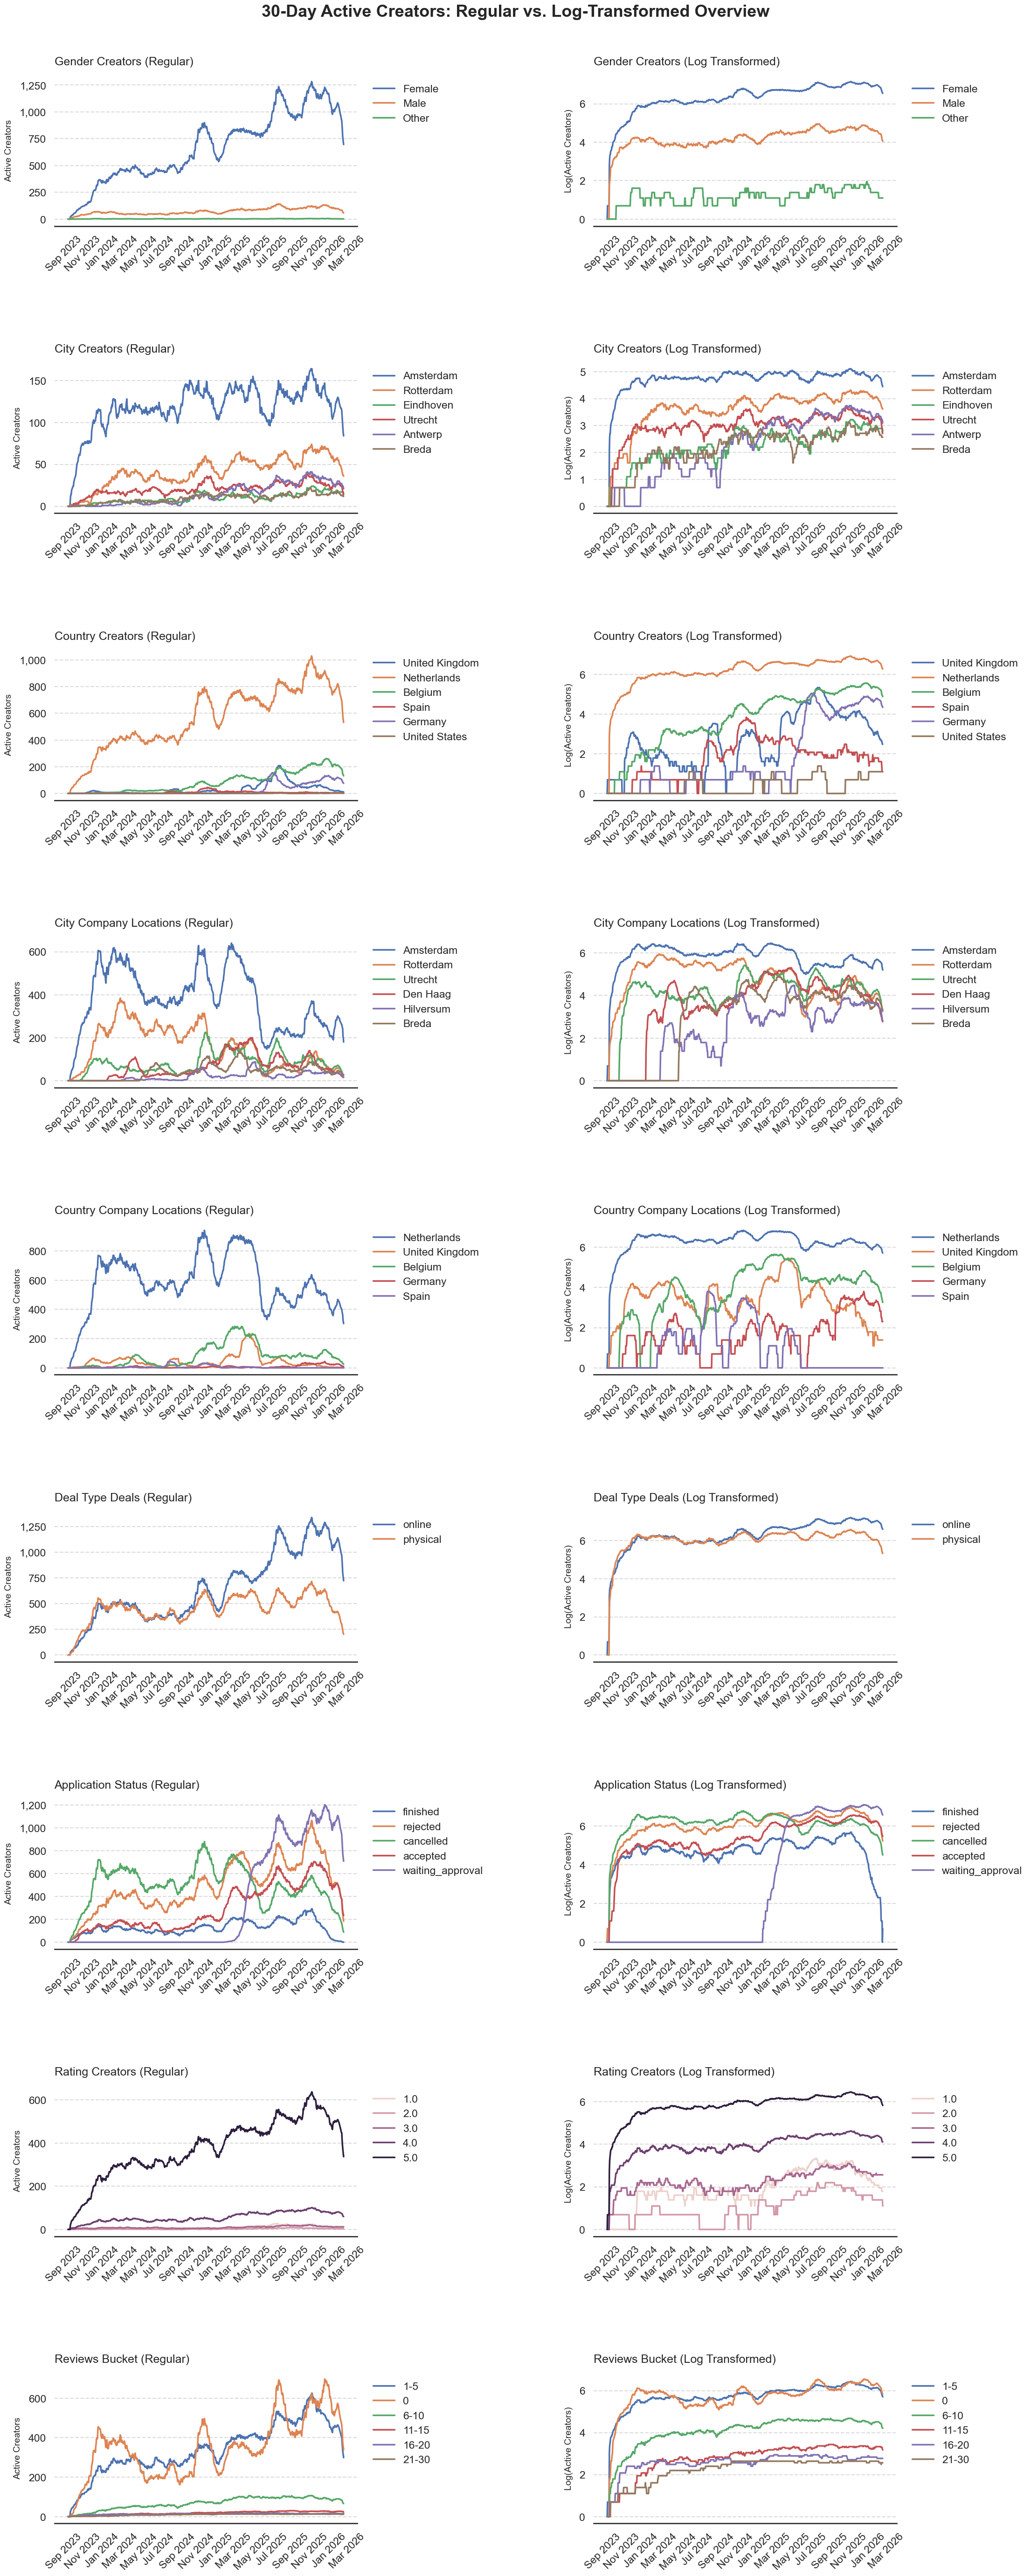

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Ensure datetime and log columns are set up
df_master_long['date'] = pd.to_datetime(df_master_long['date'])
df_master_long['log_active_last_month'] = np.log1p(df_master_long['active_last_month'])

# 1. Identify all unique categories
categories = df_master_long['category'].unique()
n_cats = len(categories)

# 2. Setup the visual theme & dynamic figure size
sns.set_theme(style="white", context="talk")
# Height scales with the number of categories (approx 6 inches per row)
fig = plt.figure(figsize=(22, 6 * n_cats), layout="constrained")

fig.suptitle('30-Day Active Creators: Regular vs. Log-Transformed Overview', 
             fontsize=26, fontweight='bold', y=1.02)

# Create an N rows x 2 columns grid
grid = fig.add_gridspec(n_cats, 2, wspace=0.15, hspace=0.25)

# 3. Loop through categories and build the rows
for i, cat in enumerate(categories):
    # Filter the dataframe for the current category
    df_cat = df_master_long[df_master_long['category'] == cat].copy()
    
    # Optional but recommended: Keep only top 5 values per category to avoid messy "spaghetti" lines
    latest_date = df_cat['date'].max()
    top_vals = df_cat[df_cat['date'] == latest_date].nlargest(6, 'active_last_month')['value']
    df_cat = df_cat[df_cat['value'].isin(top_vals)]
    
    # Format the category name for the title
    clean_title = str(cat).replace('_', ' ').title()

    # ==========================================
    # LEFT PANEL: Regular Data
    # ==========================================
    ax_reg = fig.add_subplot(grid[i, 0])
    sns.lineplot(
        data=df_cat, x='date', y='active_last_month', hue='value',
        linewidth=2.5, ax=ax_reg
    )
    ax_reg.set_title(f'{clean_title} (Regular)', fontsize=18, pad=15, loc='left')
    ax_reg.set_ylabel('Active Creators', fontsize=14, labelpad=10)
    
    # Apply thousands separator formatting to regular data
    ax_reg.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    # ==========================================
    # RIGHT PANEL: Log Transformed Data
    # ==========================================
    ax_log = fig.add_subplot(grid[i, 1])
    sns.lineplot(
        data=df_cat, x='date', y='log_active_last_month', hue='value',
        linewidth=2.5, ax=ax_log
    )
    ax_log.set_title(f'{clean_title} (Log Transformed)', fontsize=18, pad=15, loc='left')
    ax_log.set_ylabel('Log(Active Creators)', fontsize=14, labelpad=10)

    # ==========================================
    # GLOBAL FORMATTING FOR BOTH PANELS
    # ==========================================
    for ax in [ax_reg, ax_log]:
        # Date Formatting
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('') 
        
        # Clean aesthetics
        sns.despine(ax=ax, left=True)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Move legend outside the plot so it doesn't overlap lines
        if ax.get_legend():
            ax.legend(title='', frameon=False, loc='upper left', bbox_to_anchor=(1.02, 1))

# plt.savefig('all_categories_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. SETUP WIDGETS
# ==========================================
categories = sorted(cols_to_segment)
filter_categories = ['None'] + categories

# Top Row: Filtering & Main Category
dropdown_plot_cat = widgets.Dropdown(options=categories, description='View Metric:', style={'description_width': 'initial'})
dropdown_filter_cat = widgets.Dropdown(options=filter_categories, description='Filter By:', style={'description_width': 'initial'})
dropdown_filter_val = widgets.Dropdown(options=[], description='Filter Value:', style={'description_width': 'initial'}, disabled=True)

# Bottom Row: Mix % Controls
checkbox_compare = widgets.Checkbox(value=False, description='Show Mix %', indent=False)
dropdown_v1 = widgets.Dropdown(options=[], description='Base (V1):', style={'description_width': 'initial'})
dropdown_v2 = widgets.Dropdown(options=[], description='Compare (V2):', style={'description_width': 'initial'})

# ==========================================
# 2. UI INTERACTIVITY (Callbacks)
# ==========================================
def update_filter_values(*args):
    """Populates filter values dynamically."""
    selected_filter = dropdown_filter_cat.value
    if selected_filter == 'None':
        dropdown_filter_val.options = []
        dropdown_filter_val.disabled = True
    else:
        unique_vals = df_apps_filtered[selected_filter].dropna().unique().tolist()
        dropdown_filter_val.options = sorted(unique_vals)
        dropdown_filter_val.disabled = False

def update_compare_values(*args):
    """Populates V1/V2 options based on the primary viewing metric."""
    selected_cat = dropdown_plot_cat.value
    # Use global top values for the dropdown options so they don't break during filtering
    top_vals = df_apps_filtered[selected_cat].value_counts().index.tolist()
    
    dropdown_v1.options = top_vals
    dropdown_v2.options = top_vals
    if len(top_vals) > 0: dropdown_v1.value = top_vals[0]
    if len(top_vals) > 1: dropdown_v2.value = top_vals[1]

def toggle_compare_visibility(*args):
    """Hides/Shows the V1 and V2 dropdowns."""
    display_mode = 'flex' if checkbox_compare.value else 'none'
    dropdown_v1.layout.display = display_mode
    dropdown_v2.layout.display = display_mode

dropdown_filter_cat.observe(update_filter_values, 'value')
dropdown_plot_cat.observe(update_compare_values, 'value')
checkbox_compare.observe(toggle_compare_visibility, 'value')

# Initialize state
update_compare_values()
toggle_compare_visibility()

# ==========================================
# 3. ON-THE-FLY PLOTTING ENGINE
# ==========================================
def render_ultimate_dashboard(plot_cat, filter_cat, filter_val, show_compare, val_1, val_2):
    # 1. Start with raw cleaned data
    df_current = df_apps_filtered.copy()
    title_suffix = ""
    
    # 2. Apply Cross-Filter
    if filter_cat != 'None' and filter_val:
        df_current = df_current[df_current[filter_cat] == filter_val]
        title_suffix = f"<br><sup>Filtered to: {filter_cat.replace('_', ' ').title()} = {filter_val}</sup>"
        
        if df_current.empty:
            print(f"No data available for {filter_val}.")
            return

    # 3. Universal Date Ranges (Keeps the X-Axis stable across clicks)
    dateranges = pd.date_range(
        start=df_apps_filtered['application_created_at'].min().normalize(), 
        end=df_apps_filtered['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    # 4. Decide what to calculate (Optimization)
    if show_compare:
        vals_to_compute = [val_1, val_2]
        if val_1 == val_2:
            print("Please select two distinct sub-categories to compare.")
            return
    else:
        # Just grab the top 5 most frequent values in this filtered slice to save time
        vals_to_compute = df_current[plot_cat].value_counts().nlargest(5).index.tolist()

    # 5. Run the Sliding Window
    all_segments = []
    for val in vals_to_compute:
        df_subset = df_current[df_current[plot_cat] == val]
        
        event_dates = df_subset['application_created_at'].astype('int64').values
        influencers = df_subset['creator_id'].values
        
        active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
        
        all_segments.append(pd.DataFrame({
            'date': dateranges,
            'value': val,
            'active_last_month': active_30
        }))
        
    df_plot = pd.concat(all_segments, ignore_index=True)
    
    # ==========================================
    # 6. ROUTING: MIX % vs. STANDARD PLOT
    # ==========================================
    if show_compare:
        df_pivot = df_plot.pivot(index='date', columns='value', values='active_last_month')
        
        # Calculate Mix (handle division by zero if both are 0)
        df_pivot['Mix %'] = (df_pivot[val_1] / (df_pivot[val_1] + df_pivot[val_2])) * 100
        df_pivot.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        df_final = df_pivot[['Mix %']].dropna(how='all').reset_index()
        
        fig = px.line(
            df_final, x='date', y='Mix %',
            title=f'Mix Percentage: {str(plot_cat).title()} ({val_1} Share vs {val_2}){title_suffix}',
            template='plotly_white'
        )
        fig.update_yaxes(range=[0, 100], ticksuffix="%")
        fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, annotation_text="50% Parity")

    else:
        fig = px.line(
            df_plot, x='date', y='active_last_month', color='value',
            title=f'Active Creators by {plot_cat.replace("_", " ").title()}{title_suffix}',
            template='plotly_white'
        )
        fig.update_yaxes(title='30-Day Active Creators')

    # Global Formatting
    fig.update_traces(line=dict(width=2), marker=dict(size=4, opacity=0.7, line=dict(width=0)))
    fig.update_yaxes(showgrid=True, gridcolor='LightGray')
    fig.update_layout(
        hovermode="x unified",
        legend_title_text='Sub-Category' if not show_compare else None,
        margin=dict(t=80, b=40, l=40, r=40),
        height=600
    )
    
    fig.show()

# ==========================================
# 7. RENDER THE FULL UI
# ==========================================
ui = widgets.VBox([
    widgets.HBox([dropdown_plot_cat, dropdown_filter_cat, dropdown_filter_val]),
    widgets.HBox([checkbox_compare, dropdown_v1, dropdown_v2])
])

out = widgets.interactive_output(render_ultimate_dashboard, {
    'plot_cat': dropdown_plot_cat,
    'filter_cat': dropdown_filter_cat,
    'filter_val': dropdown_filter_val,
    'show_compare': checkbox_compare,
    'val_1': dropdown_v1,
    'val_2': dropdown_v2
})

display(ui, out)

Output()

In [31]:
import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
include_log_transform = False # Set to True if you want log charts on standard view

if include_log_transform:
    df_master_long['log_active_last_month'] = np.log1p(df_master_long['active_last_month'])
else:
    if 'log_active_last_month' in df_master_long.columns:
        df_master_long.drop(columns='log_active_last_month', inplace=True)

df_master_long['date'] = pd.to_datetime(df_master_long['date'])
categories = sorted(df_master_long['category'].unique())

# ==========================================
# 2. CREATE WIDGETS
# ==========================================
dropdown_cat = widgets.Dropdown(options=categories, description='Category:', style={'description_width': 'initial'})
checkbox_compare = widgets.Checkbox(value=False, description='Show Mix %', indent=False)

# Get initial options for the sub-dropdowns
initial_options = df_master_long[df_master_long['category'] == categories[0]]['value'].unique().tolist()

dropdown_v1 = widgets.Dropdown(options=initial_options, description='Base (V1):', style={'description_width': 'initial'})
dropdown_v2 = widgets.Dropdown(options=initial_options, description='Compare (V2):', style={'description_width': 'initial'})

# ==========================================
# 3. WIDGET INTERACTIVITY LOGIC
# ==========================================
def update_sub_dropdowns(*args):
    """Updates V1 and V2 options whenever the main Category changes."""
    selected_cat = dropdown_cat.value
    df_cat = df_master_long[df_master_long['category'] == selected_cat]
    latest_date = df_cat['date'].max()
    new_options = df_cat[df_cat['date'] == latest_date].sort_values('active_last_month', ascending=False)['value'].tolist()
    
    dropdown_v1.options = new_options
    dropdown_v2.options = new_options
    
    if len(new_options) > 0: dropdown_v1.value = new_options[0]
    if len(new_options) > 1: dropdown_v2.value = new_options[1]

def toggle_compare_visibility(*args):
    """Hides the V1/V2 dropdowns when the checkbox is unticked."""
    display_mode = 'flex' if checkbox_compare.value else 'none'
    dropdown_v1.layout.display = display_mode
    dropdown_v2.layout.display = display_mode

dropdown_cat.observe(update_sub_dropdowns, 'value')
checkbox_compare.observe(toggle_compare_visibility, 'value')

update_sub_dropdowns()
toggle_compare_visibility()

# ==========================================
# 4. PLOTTING FUNCTION
# ==========================================
def render_plot(category, show_compare, val_1, val_2):
    df_cat = df_master_long[df_master_long['category'] == category].copy()
    
    # --- RELATIVE GROWTH (MIX %) PLOT ---
    if show_compare:
        if not val_1 or not val_2 or val_1 == val_2:
            print("Please select two distinct sub-categories to compare.")
            return
            
        df_sub = df_cat[df_cat['value'].isin([val_1, val_2])]
        df_pivot = df_sub.pivot(index='date', columns='value', values='active_last_month')
        
        # Calculate Mix % (V1 as a percentage of V1+V2)
        df_pivot['Mix %'] = (df_pivot[val_1] / (df_pivot[val_1] + df_pivot[val_2])) * 100
        df_pivot.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        df_plot = df_pivot[['Mix %']].dropna().reset_index()
        
        fig = px.line(
            df_plot, x='date', y='Mix %',
            title=f'Mix Percentage: {str(category).title()} ({val_1} Share vs {val_2})',
            template='plotly_white'
        )
        
        # Lock Y-Axis to 0-100 and add % sign
        fig.update_yaxes(range=[0, 100], ticksuffix="%")
        fig.add_hline(y=50, line_dash="dash", line_color="red", opacity=0.5, annotation_text="50% Parity")

    # --- STANDARD CATEGORY PLOT ---
    else:
        latest_date = df_cat['date'].max()
        top_vals = df_cat[df_cat['date'] == latest_date].nlargest(5, 'active_last_month')['value']
        df_cat = df_cat[df_cat['value'].isin(top_vals)]
        
        value_vars = ['active_last_month']
        if include_log_transform: value_vars.append('log_active_last_month')

        df_plot = df_cat.melt(
            id_vars=['date', 'value'], value_vars=value_vars,
            var_name='Metric', value_name='Count'
        )
        
        fig = px.line(
            df_plot, x='date', y='Count', color='value', 
            facet_col='Metric' if include_log_transform else None,
            title=f'Active Creators: {str(category).replace("_", " ").title()}',
            template='plotly_white'
        )
        fig.update_yaxes(matches=None) # Ensure regular plots auto-scale normally

    # --- SHARED FORMATTING ---
    fig.update_traces(line=dict(width=2), marker=dict(size=4, opacity=0.7, line=dict(width=0)))
    fig.update_yaxes(showgrid=True, gridcolor='LightGray')
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    
    fig.update_layout(
        hovermode="x unified",
        legend_title_text='Sub-Category' if not show_compare else None,
        margin=dict(t=80, b=40, l=40, r=40),
        height=600 
    )
    fig.show()

# ==========================================
# 5. RENDER DASHBOARD
# ==========================================
ui = widgets.VBox([
    widgets.HBox([dropdown_cat, checkbox_compare]),
    widgets.HBox([dropdown_v1, dropdown_v2])
])

out = widgets.interactive_output(render_plot, {
    'category': dropdown_cat,
    'show_compare': checkbox_compare,
    'val_1': dropdown_v1,
    'val_2': dropdown_v2
})

display(ui, out)

Output()

The nr. of different (partner) cities creators apply to
- This does not neatly follow the trend. True overall actives is on a decline, but before that, the nr. of different cities creators apply to fell very sharply. What happened between April and June 2025?

In [32]:
import pandas as pd
import plotly.express as px

# 4. Build the final DataFrame
df_active_creators = pd.DataFrame({'date': dateranges})

df_active_creators['active_last_month'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=30
)
df_active_creators['active_last_week'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=7
)

def plot_cross_pollination(df_global, df_long, category_name='city_partner'):
    """
    Calculates and plots the average number of segments a creator interacts with.
    Proves whether total volume is dropping while per-user geographic spread is rising.
    """
    # 1. Sum up all the active users across every segment in the category (e.g., all cities)
    df_cat = df_long[df_long['category'] == category_name].copy()
    df_sum = df_cat.groupby('date')['active_last_month'].sum().reset_index()
    df_sum.rename(columns={'active_last_month': 'Sum of Segmented Actives'}, inplace=True)
    
    # 2. Merge with your true global active count
    # (Using the df_active_creators dataframe you built previously)
    df_merge = pd.merge(
        df_global[['date', 'active_last_month']], 
        df_sum, 
        on='date', 
        how='inner'
    )
    df_merge.rename(columns={'active_last_month': 'True Overall Actives'}, inplace=True)
    
    # 3. Calculate the Ratio (Average Cities per Creator)
    df_merge['Average Segments per Creator'] = df_merge['Sum of Segmented Actives'] / df_merge['True Overall Actives']
    
    # 4. Melt for a side-by-side Plotly facet chart
    df_plot = df_merge.melt(
        id_vars='date', 
        value_vars=['True Overall Actives', 'Average Segments per Creator'],
        var_name='Metric', 
        value_name='Value'
    )
    
    # 5. Plot the divergence
    fig = px.line(
        df_plot, 
        x='date', 
        y='Value', 
        facet_col='Metric',
        title=f'Divergence Check: Overall Actives vs. Geographic Spread ({str(category_name).title()})',
        template='plotly_white'
    )
    
    # Allow independent Y-axes so the ratio (e.g., 1.5) isn't flattened by the total count (e.g., 50,000)
    fig.update_yaxes(matches=None, showgrid=True, gridcolor='LightGray')
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    
    fig.update_layout(
        hovermode="x unified",
        margin=dict(t=60, b=40, l=40, r=40),
        height=500 
    )
    
    fig.show()

# --- How to use it ---
# Pass in your global dataframe and your long dataframe, and tell it which category to check
plot_cross_pollination(df_active_creators, df_master_long, category_name='city_company_locations')

-------

__Left Chart (Ratio V1​/V2​)__: 
- If the line trends upward, V1​ (e.g., Online) is growing faster than V2​ (e.g., Physical). If it hits the red dashed line at 1.0, they have equal volume. If it is flat, their growth is perfectly cointegrated.

__Right Chart (Mix %)__: 
- This shows the exact same mathematical relationship but bounds it between 0% and 100%. If the line moves from 60% to 70%, V1​ is capturing a larger share of your total business. The red dashed line sits at 50%.

In [33]:
import pandas as pd
import numpy as np
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. SETUP & CONFIGURATION
# ==========================================
include_log_transform = False # Set to True if you want log charts on the standard view

if include_log_transform:
    df_master_long['log_active_last_month'] = np.log1p(df_master_long['active_last_month'])
else:
    if 'log_active_last_month' in df_master_long.columns:
        df_master_long.drop(columns='log_active_last_month', inplace=True)

df_master_long['date'] = pd.to_datetime(df_master_long['date'])
categories = sorted(df_master_long['category'].unique())

# ==========================================
# 2. CREATE WIDGETS
# ==========================================
dropdown_cat = widgets.Dropdown(options=categories, description='Category:', style={'description_width': 'initial'})
checkbox_compare = widgets.Checkbox(value=False, description='Compare Relative Growth', indent=False)

# Get initial options for the sub-dropdowns based on the first category
initial_options = df_master_long[df_master_long['category'] == categories[0]]['value'].unique().tolist()

dropdown_v1 = widgets.Dropdown(options=initial_options, description='Base (V1):', style={'description_width': 'initial'})
dropdown_v2 = widgets.Dropdown(options=initial_options, description='Compare (V2):', style={'description_width': 'initial'})

# ==========================================
# 3. WIDGET INTERACTIVITY LOGIC
# ==========================================
def update_sub_dropdowns(*args):
    """Updates V1 and V2 options whenever the main Category changes."""
    selected_cat = dropdown_cat.value
    df_cat = df_master_long[df_master_long['category'] == selected_cat]
    latest_date = df_cat['date'].max()
    new_options = df_cat[df_cat['date'] == latest_date].sort_values('active_last_month', ascending=False)['value'].tolist()
    
    dropdown_v1.options = new_options
    dropdown_v2.options = new_options
    
    # Auto-select the top 2 if possible
    if len(new_options) > 0: dropdown_v1.value = new_options[0]
    if len(new_options) > 1: dropdown_v2.value = new_options[1]

def toggle_compare_visibility(*args):
    """Hides the V1/V2 dropdowns when the checkbox is unticked."""
    display_mode = 'flex' if checkbox_compare.value else 'none'
    dropdown_v1.layout.display = display_mode
    dropdown_v2.layout.display = display_mode

dropdown_cat.observe(update_sub_dropdowns, 'value')
checkbox_compare.observe(toggle_compare_visibility, 'value')

update_sub_dropdowns()
toggle_compare_visibility()

# ==========================================
# 4. PLOTTING FUNCTION
# ==========================================
def render_plot(category, show_compare, val_1, val_2):
    df_cat = df_master_long[df_master_long['category'] == category].copy()
    
    # --- RELATIVE GROWTH PLOT ---
    if show_compare:
        if not val_1 or not val_2 or val_1 == val_2:
            print("Please select two distinct sub-categories to compare.")
            return
            
        df_sub = df_cat[df_cat['value'].isin([val_1, val_2])]
        df_pivot = df_sub.pivot(index='date', columns='value', values='active_last_month')
        
        # Calculate Relative Metrics
        df_pivot['Ratio (V1 / V2)'] = df_pivot[val_1] / df_pivot[val_2]
        df_pivot[f'Mix % ({val_1})'] = (df_pivot[val_1] / (df_pivot[val_1] + df_pivot[val_2])) * 100
        
        # Clean up divide-by-zero infinities if V2 ever drops to 0
        df_pivot.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Melt for side-by-side subplots
        df_plot = df_pivot[['Ratio (V1 / V2)', f'Mix % ({val_1})']].dropna(how='all').reset_index()
        df_plot = df_plot.melt(id_vars='date', var_name='Metric', value_name='Value')
        
        fig = px.line(
            df_plot, x='date', y='Value', facet_col='Metric',
            title=f'Relative Growth: {str(category).title()} ({val_1} vs {val_2})',
            template='plotly_white'
        )
        
        # Add logical baseline reference lines to specific subplots
        fig.add_hline(y=1, col=1, line_dash="dash", line_color="red", opacity=0.5, annotation_text="1:1 Parity")
        fig.add_hline(y=50, col=2, line_dash="dash", line_color="red", opacity=0.5, annotation_text="50% Mix Parity")

    # --- STANDARD CATEGORY PLOT ---
    else:
        latest_date = df_cat['date'].max()
        top_vals = df_cat[df_cat['date'] == latest_date].nlargest(5, 'active_last_month')['value']
        df_cat = df_cat[df_cat['value'].isin(top_vals)]
        
        value_vars = ['active_last_month']
        if include_log_transform: value_vars.append('log_active_last_month')

        df_plot = df_cat.melt(
            id_vars=['date', 'value'], value_vars=value_vars,
            var_name='Metric', value_name='Count'
        )
        
        fig = px.line(
            df_plot, x='date', y='Count', color='value', 
            facet_col='Metric' if include_log_transform else None,
            title=f'Active Creators: {str(category).replace("_", " ").title()}',
            template='plotly_white'
        )

    # --- SHARED FORMATTING ---
    fig.update_traces(line=dict(width=2), marker=dict(size=4, opacity=0.7, line=dict(width=0)))
    fig.update_yaxes(matches=None, showgrid=True, gridcolor='LightGray')
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    
    fig.update_layout(
        hovermode="x unified",
        legend_title_text='Sub-Category' if not show_compare else None,
        margin=dict(t=80, b=40, l=40, r=40),
        height=600 
    )
    fig.show()

# ==========================================
# 5. RENDER DASHBOARD
# ==========================================
ui = widgets.VBox([
    widgets.HBox([dropdown_cat, checkbox_compare]),
    widgets.HBox([dropdown_v1, dropdown_v2])
])

out = widgets.interactive_output(render_plot, {
    'category': dropdown_cat,
    'show_compare': checkbox_compare,
    'val_1': dropdown_v1,
    'val_2': dropdown_v2
})

display(ui, out)

Output()

## Cross-product of categories

Every combination of the categories we consider (e.g., gender, location) is considered. Can groupby and compute statistics. Warning: almost 8GB in size

In [ ]:
df_apps.created_at_company_locations

In [ ]:
df_apps.city_company_locations

In [38]:
import pandas as pd
from collections import defaultdict

def get_multidimensional_actives(df, segment_cols):
    """
    Calculates rolling active unique creators for any combination of columns.
    """
    # 1. Sort the main dataframe (CRITICAL)
    df = df.sort_values('application_created_at').reset_index(drop=True)
    
    # 2. Establish the universal daily date range
    dateranges = pd.date_range(
        start=df['application_created_at'].min().normalize(), 
        end=df['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    all_segments = []
    
    # 3. Group by the list of columns
    # dropna=False ensures we don't lose rows where e.g., 'city_partner' is missing
    grouped = df.groupby(segment_cols, dropna=False)
    
    for group_keys, df_subset in grouped:
        # Map the group values back to their column names
        # (Handles both single-column strings and multi-column tuples)
        if isinstance(group_keys, tuple):
            group_dict = dict(zip(segment_cols, group_keys))
        else:
            group_dict = {segment_cols[0]: group_keys}
            
        # Extract arrays for this specific subgroup
        event_dates = df_subset['application_created_at'].astype('int64').values
        influencers = df_subset['creator_id'].values
        
        # Calculate the metrics
        active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
        active_7 = get_daily_uniques(target_dates_ns, event_dates, influencers, 7)
        
        # Build the Tidy DataFrame for this specific combination
        df_temp = pd.DataFrame({'date': dateranges})
        
        # Unpack the category columns into the dataframe
        for col, val in group_dict.items():
            df_temp[col] = val
            
        df_temp['active_last_month'] = active_30
        df_temp['active_last_week'] = active_7
        
        all_segments.append(df_temp)
        
    # 4. Combine everything into one master DataFrame
    return pd.concat(all_segments, ignore_index=True)

# --- How to run it on your specific columns ---
cols_to_segment = [
    'gender_creators', 
    # 'address_name', 
    'country_creators', 
    'city_company_locations', 
    'country_company_locations'
]

df_master_long = get_multidimensional_actives(df_apps, cols_to_segment)

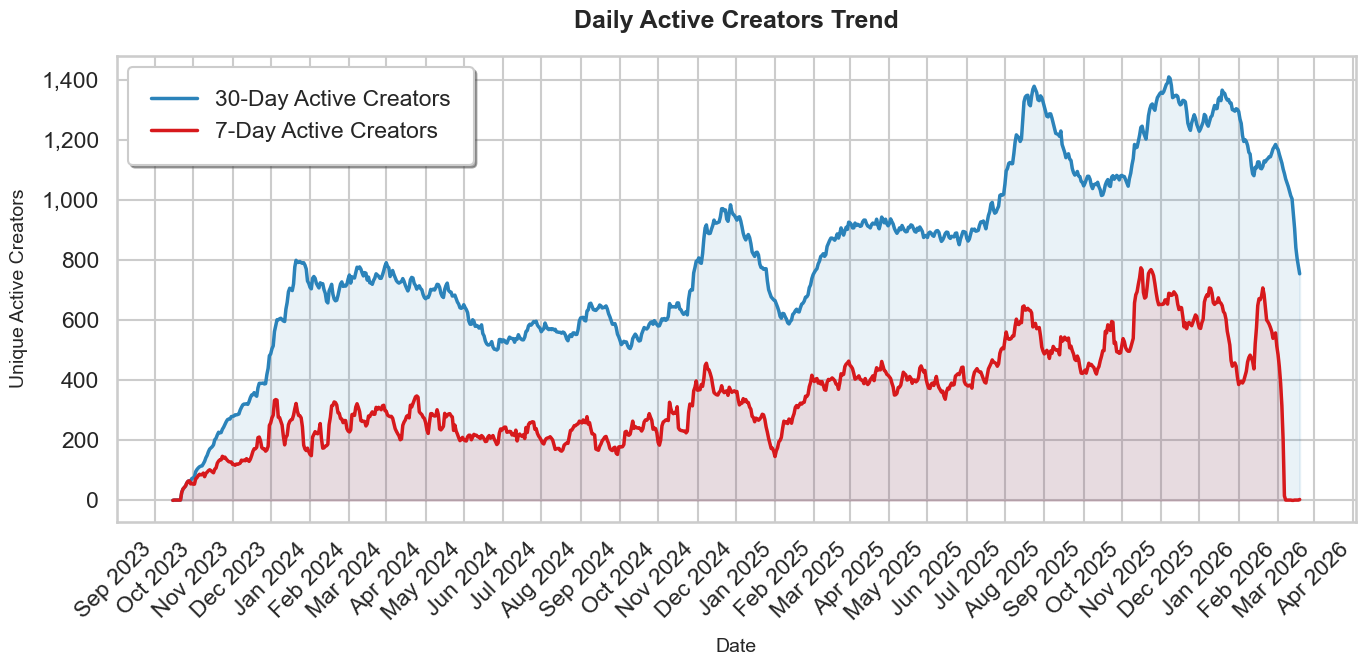

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set the theme for a clean, modern look
sns.set_theme(style="whitegrid", context="talk")

# 1. Initialize the figure size
plt.figure(figsize=(14, 7))

# 2. Plot the main lines
# Use slightly thicker lines and distinct colors for readability
plt.plot(df_active_creators['date'], df_active_creators['active_last_month'], 
         label='30-Day Active Creators', color='#2b83ba', linewidth=2.5)
plt.plot(df_active_creators['date'], df_active_creators['active_last_week'], 
         label='7-Day Active Creators', color='#d7191c', linewidth=2.5)

# 3. Add a subtle fill below the lines for a polished, "dashboard" effect
plt.fill_between(df_active_creators['date'], df_active_creators['active_last_month'], 
                 color='#2b83ba', alpha=0.1)
plt.fill_between(df_active_creators['date'], df_active_creators['active_last_week'], 
                 color='#d7191c', alpha=0.1)

# 4. Formatting the Title and Axes
plt.title('Daily Active Creators Trend', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, labelpad=10)
plt.ylabel('Unique Active Creators', fontsize=14, labelpad=10)

ax = plt.gca()

# 5. Beautiful Date Formatting on the x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator())        # Tick marks on months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # E.g., "Jan 2024"
plt.xticks(rotation=45, ha='right')

# 6. Add thousands separator to y-axis (e.g., "1,500" instead of "1500")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 7. Style the legend
plt.legend(loc='upper left', frameon=True, shadow=True, fancybox=True, borderpad=1)

# Ensure everything fits perfectly without getting cut off
plt.tight_layout()

# Save or display
# plt.savefig('active_creators_viz.png', dpi=300, bbox_inches='tight')
# plt.show()

In [44]:
import pandas as pd
import numpy as np
from collections import defaultdict

# 1. Sort the raw data (CRITICAL)
df_apps = df_apps.sort_values('application_created_at').reset_index(drop=True)

# 2. Extract arrays to nanoseconds for speed
event_dates = df_apps['application_created_at'].astype('int64').values
influencers = df_apps['creator_id'].values

# 3. Create your daily date range (normalized to midnight for clean daily buckets)
dateranges = pd.date_range(
    start=df_apps['application_created_at'].min().normalize(), 
    end=df_apps['application_created_at'].max().normalize(), 
    freq='D'
)
# Convert the target daily dates to nanoseconds
target_dates_ns = dateranges.astype('int64').values


# Helper function from our previous step
def get_daily_uniques(target_dates_ns, event_dates, influencers, window_days):
    window_ns = pd.Timedelta(days=window_days).value
    n_events = len(event_dates)
    results = []
    
    counts = defaultdict(int)
    unique_count = 0
    left_ptr = 0
    right_ptr = 0
    
    for current_day_ns in target_dates_ns:
        min_time_ns = current_day_ns - window_ns
        
        while right_ptr < n_events and event_dates[right_ptr] < current_day_ns:
            inf = influencers[right_ptr]
            if counts[inf] == 0: unique_count += 1
            counts[inf] += 1
            right_ptr += 1
            
        while left_ptr < right_ptr and event_dates[left_ptr] <= min_time_ns:
            inf = influencers[left_ptr]
            counts[inf] -= 1
            if counts[inf] == 0: unique_count -= 1
            left_ptr += 1
            
        results.append(unique_count)
    return results


def get_segmented_actives(df, segment_col):
    """
    Calculates 7-day and 30-day active unique creators grouped by a specific column.
    """
    # 1. Sort the main dataframe once (CRITICAL)
    df = df.sort_values('application_created_at').reset_index(drop=True)
    
    # 2. Establish the universal daily date range
    dateranges = pd.date_range(
        start=df['application_created_at'].min().normalize(), 
        end=df['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    # 3. List to store the results for each segment
    all_segments = []
    
    # 4. Find all unique categories in your chosen column (dropping NaNs for clean groups)
    unique_categories = df[segment_col].dropna().unique()
    
    for category in unique_categories:
        # Filter for the specific category
        df_subset = df[df[segment_col] == category]
        
        # Extract arrays for this specific group
        event_dates = df_subset['application_created_at'].astype('int64').values
        influencers = df_subset['creator_id'].values
        
        # Calculate the metrics using our fast helper
        active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
        active_7 = get_daily_uniques(target_dates_ns, event_dates, influencers, 7)
        
        # Build a "Tidy" dataframe for this category
        df_temp = pd.DataFrame({
            'date': dateranges,
            segment_col: category,
            'active_last_month': active_30,
            'active_last_week': active_7
        })
        
        all_segments.append(df_temp)
        
    # 5. Combine everything into one master DataFrame
    return pd.concat(all_segments, ignore_index=True)

# --- How to use it ---
# Get active users split by Gender
df_gender = get_segmented_actives(df_apps, 'gender_creators')

# Get active users split by Country
df_country = get_segmented_actives(df_apps, 'country_creators')

In [48]:
df_country

,date,country_creators,active_last_month,active_last_week
0,2023-09-15,United Kingdom,0,0
1,2023-09-16,United Kingdom,1,1
2,2023-09-17,United Kingdom,1,1
3,2023-09-18,United Kingdom,1,1
4,2023-09-19,United Kingdom,1,1
...,...,...,...,...
13315,2026-02-14,Ukraine,0,0
13316,2026-02-15,Ukraine,0,0
13317,2026-02-16,Ukraine,0,0
13318,2026-02-17,Ukraine,0,0


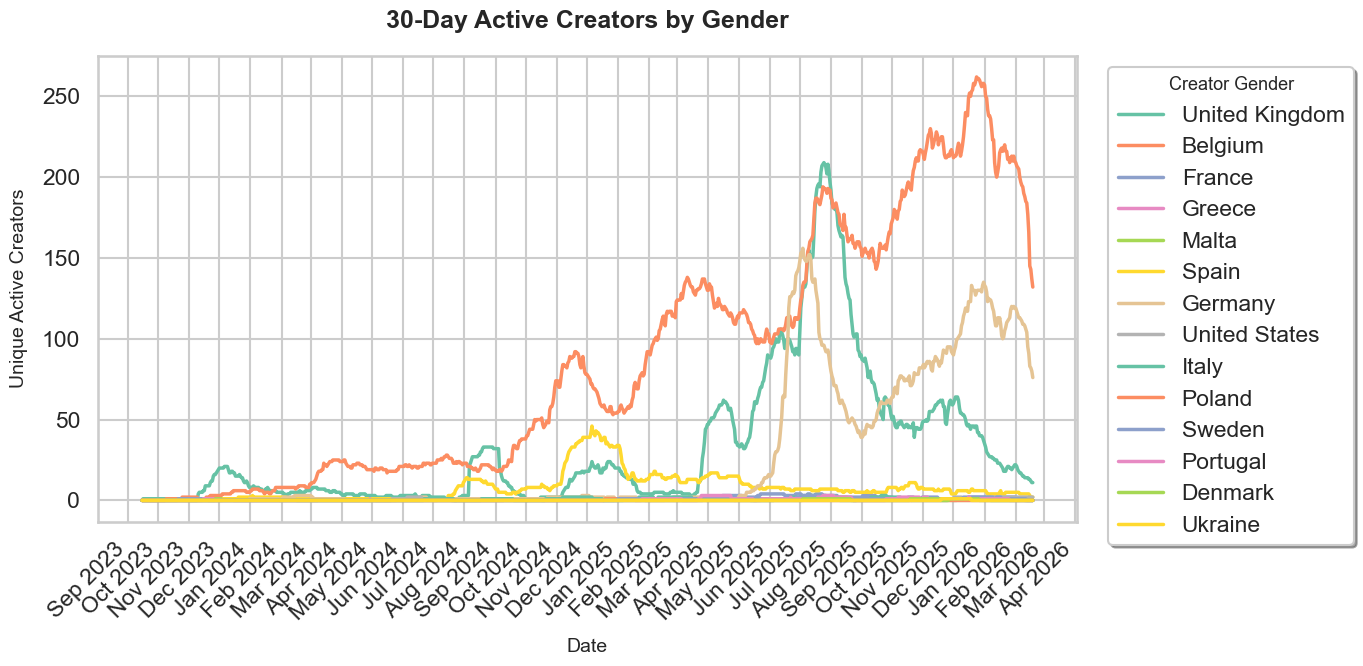

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


# 1. Set the visual theme
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 7))

# 2. Plot using Seaborn's native 'hue' parameter
# This automatically creates a line for Male, Female, Other, etc.
ax = sns.lineplot(
    data=df_country[df_country['country_creators'] != 'Netherlands'], 
    x='date', 
    y='active_last_month', 
    hue='country_creators',  # This is the magic parameter!
    linewidth=2.5,
    palette='Set2'         # A clean, colorblind-friendly palette
)

# 3. Formatting Title and Axes
plt.title('30-Day Active Creators by Gender', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=14, labelpad=10)
plt.ylabel('Unique Active Creators', fontsize=14, labelpad=10)

# 4. Beautiful Date Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

# 5. Add thousands separator to the y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 6. Clean up the legend
# We move it slightly outside the plot area so it doesn't cover your data lines
plt.legend(
    title='Creator Gender', 
    title_fontsize='13', 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), # Pushes legend outside the right edge
    frameon=True, 
    shadow=True
)

# Ensure nothing gets cut off (especially the external legend)
plt.tight_layout()

# Save or display
plt.savefig('segmented_active_creators.png', dpi=300, bbox_inches='tight')
# plt.show()

# Online database

In [ ]:
# Load environment variables from .env file
load_dotenv("../private_data/.env")

host = os.getenv("HOST")
db = os.getenv("DB")
port = os.getenv("PORT")
role = os.getenv("ROLE")
pw = os.getenv("PASSWORD")
engine = create_engine(f"postgresql+psycopg2://{role}:{pw}@{host}:{port}/{db}")

# Partners

In [ ]:
query = 'SELECT * FROM public.partners;'

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_partners = pd.read_sql(text(query), connection)

In [ ]:
df_partners

,legacy_id,user_id,name,customer_id,status,created_at,updated_at,deleted_at,tags,id,company_name,company_size,website,worked_with_creators,references,reference_reason
0,2418,50843,Derrick Homenick,,PhoneNumberVerification,2025-09-10 10:22:57.281581+00:00,2025-09-10 10:22:57.462205+00:00,None,None,01993326-6101-0065-d61a-bd22529ce9d4,,None,,None,None,
1,2423,50849,Maudie Robel,,PhoneNumberVerification,2025-09-10 10:53:28.037275+00:00,2025-09-10 10:53:28.195740+00:00,None,None,01993342-5065-0065-07e9-732563162928,,None,,None,None,
2,2466,51011,Mr. Randy Towne,,Active,2025-09-11 13:37:35.616499+00:00,2026-01-12 07:33:52.670102+00:00,None,[partner.companies_migration_phase1],019938fe-ef2f-0065-e1c4-ab707831a79c,Pasje.pro,xs,https://pasje.pro,False,{email},
3,2473,51059,Yolanda Simonis,,Active,2025-09-12 07:53:59.137731+00:00,2026-01-12 07:33:56.151421+00:00,None,[partner.companies_migration_phase1],01993cea-b637-0065-7b0e-11a4e54df9bb,Casa Vivida,xs,https://casa-vivida.com/,False,{google},
4,2515,51315,Mara Rempel,,Active,2025-09-16 11:56:12.117224+00:00,2026-01-12 07:34:09.754172+00:00,None,[partner.companies_migration_phase1],01995261-e7d5-0065-a052-db1b9956bdcd,jomaroto Cosmetics GmbH,xs,h-rootine.de,False,"{google,social_media,newsletter,other}",Instagram
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933,0,66776,Testing,,CompanyInformation,2026-02-10 16:22:22.864561+00:00,2026-02-10 16:22:28.397058+00:00,None,None,019c485c-6d90-0065-5aaf-dcdf141ae162,,None,,None,None,
3934,0,66771,Test Account,,Active,2026-02-04 14:45:59.787184+00:00,2026-02-04 14:46:14.780617+00:00,None,None,019c291e-076b-0065-d02d-f89615aff7ea,Trolhas,xs,Trolhas.com,True,{recommendation},
3935,0,66778,nice,,PhoneNumberVerification,2026-02-10 16:32:54.461092+00:00,2026-02-10 16:32:54.563914+00:00,None,None,019c4866-10bd-0065-11b2-609ee1a5821b,,None,,None,None,
3936,0,66779,testingdev,,SubscriptionPlan,2026-02-10 16:33:33.759390+00:00,2026-02-10 16:33:51.198583+00:00,None,None,019c4866-aa3f-0065-0875-7af641c88bca,312321321,xs,3123213213,True,"{webinar,online_ad}",


In [ ]:
df_partners.isna().sum()

legacy_id                  0
user_id                    0
name                       0
customer_id                0
status                     0
created_at                 0
updated_at                 0
deleted_at              3938
tags                    1465
id                         0
company_name            2172
company_size            2948
website                 2172
worked_with_creators    2948
references              2949
reference_reason        2172
dtype: int64

In [ ]:
df_partners

,legacy_id,user_id,name,customer_id,status,created_at,updated_at,deleted_at,tags,id,company_name,company_size,website,worked_with_creators,references,reference_reason
0,2418,50843,Derrick Homenick,,PhoneNumberVerification,2025-09-10 10:22:57.281581+00:00,2025-09-10 10:22:57.462205+00:00,None,None,01993326-6101-0065-d61a-bd22529ce9d4,,None,,None,None,
1,2423,50849,Maudie Robel,,PhoneNumberVerification,2025-09-10 10:53:28.037275+00:00,2025-09-10 10:53:28.195740+00:00,None,None,01993342-5065-0065-07e9-732563162928,,None,,None,None,
2,2466,51011,Mr. Randy Towne,,Active,2025-09-11 13:37:35.616499+00:00,2026-01-12 07:33:52.670102+00:00,None,[partner.companies_migration_phase1],019938fe-ef2f-0065-e1c4-ab707831a79c,Pasje.pro,xs,https://pasje.pro,False,{email},
3,2473,51059,Yolanda Simonis,,Active,2025-09-12 07:53:59.137731+00:00,2026-01-12 07:33:56.151421+00:00,None,[partner.companies_migration_phase1],01993cea-b637-0065-7b0e-11a4e54df9bb,Casa Vivida,xs,https://casa-vivida.com/,False,{google},
4,2515,51315,Mara Rempel,,Active,2025-09-16 11:56:12.117224+00:00,2026-01-12 07:34:09.754172+00:00,None,[partner.companies_migration_phase1],01995261-e7d5-0065-a052-db1b9956bdcd,jomaroto Cosmetics GmbH,xs,h-rootine.de,False,"{google,social_media,newsletter,other}",Instagram
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933,0,66776,Testing,,CompanyInformation,2026-02-10 16:22:22.864561+00:00,2026-02-10 16:22:28.397058+00:00,None,None,019c485c-6d90-0065-5aaf-dcdf141ae162,,None,,None,None,
3934,0,66771,Test Account,,Active,2026-02-04 14:45:59.787184+00:00,2026-02-04 14:46:14.780617+00:00,None,None,019c291e-076b-0065-d02d-f89615aff7ea,Trolhas,xs,Trolhas.com,True,{recommendation},
3935,0,66778,nice,,PhoneNumberVerification,2026-02-10 16:32:54.461092+00:00,2026-02-10 16:32:54.563914+00:00,None,None,019c4866-10bd-0065-11b2-609ee1a5821b,,None,,None,None,
3936,0,66779,testingdev,,SubscriptionPlan,2026-02-10 16:33:33.759390+00:00,2026-02-10 16:33:51.198583+00:00,None,None,019c4866-aa3f-0065-0875-7af641c88bca,312321321,xs,3123213213,True,"{webinar,online_ad}",


In [ ]:
df_partners.company_size.value_counts().sum()

np.int64(990)

In [ ]:
df_partners.isna().sum()

legacy_id                  0
user_id                    0
name                       0
customer_id                0
status                     0
created_at                 0
updated_at                 0
deleted_at              3938
tags                    1465
id                         0
company_name            2172
company_size            2948
website                 2172
worked_with_creators    2948
references              2949
reference_reason        2172
dtype: int64

In [ ]:
df_partners.references.value_counts() / df_partners.references.value_counts().sum()

references
{email}                                  0.277048
{google}                                 0.202224
{other}                                  0.150657
{recommendation}                         0.114257
{social_media}                           0.093023
                                           ...   
{social_media,creator}                   0.001011
{webinar,creator}                        0.001011
{google,online_ad,email,social_media}    0.001011
{influencer,newsletter,webinar}          0.001011
{webinar,online_ad}                      0.001011
Name: count, Length: 62, dtype: float64

# Creators

## Creators with the most apps 

In [ ]:
query = 'SELECT * FROM public.deal_applications;'
df_apps = pd.read_sql(query, engine)

In [ ]:
# Most finished deals
df_apps[df_apps.status == 'finished']['creator_id'].value_counts()

In [ ]:
# Most accepted
df_apps[df_apps.status == 'accepted']['creator_id'].value_counts()

In [ ]:
# Most cancelled
df_apps[df_apps.status == 'cancelled']['creator_id'].value_counts()

NameError: name 'df_apps' is not defined

In [ ]:
df_apps.groupby('status')['creator_id'].value_counts().reset_index()

## Live bar chart

In [ ]:
query = """
SELECT 
    id, 
    user_id,
    name, 
    rating,
    description,
    status,
    created_at,
    CAST(updated_at AS TEXT) as updated_at,
    CAST(birthday AS TEXT) as birthday,
    gender,
    reviews_count
FROM public.influencers;
"""

with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creators = pd.read_sql(text(query), connection)

query = """
SELECT 
    created_at,
    updated_at,
    influencer_id,
    name,
    country,
    latitude,
    longitude
FROM public.influencer_locations;
"""


with engine.connect() as connection:
    # 2. We don't use parse_dates=True here to avoid the crash
    df_creatorsloc = pd.read_sql(text(query), connection)


In [ ]:
# Strip the timezone from both (just to be safe)
df_creators['created_at'] = pd.to_datetime(df_creators['created_at']).dt.tz_localize(None)
df_creatorsloc['created_at'] = pd.to_datetime(df_creatorsloc['created_at']).dt.tz_localize(None)

# Now the comparison will work perfectly
mask = df_creators['created_at'] < df_creatorsloc['created_at'].min()

In [ ]:
df_creatorsloc

,created_at,updated_at,influencer_id,name,country,latitude,longitude
0,2024-10-25 09:45:27.207163,2024-10-25 09:45:27.207163,16189,Almelo,Netherlands,52.367027,6.668492
1,2024-08-29 10:29:07.467566,2024-08-29 10:29:07.467566,11181,Amsterdam,Netherlands,52.367573,4.904139
2,2024-08-29 10:49:44.860592,2024-08-29 10:49:44.860592,11182,Lelystad,Netherlands,52.518537,5.471422
3,2024-08-29 10:52:50.411597,2024-08-29 10:52:50.411597,11183,Tilburg,Netherlands,51.560596,5.091914
4,2024-08-29 10:57:20.398272,2024-08-29 10:57:20.398272,11184,Amsterdam,Netherlands,52.367573,4.904139
...,...,...,...,...,...,...,...
19700,2026-01-29 23:26:56.191576,2026-01-29 23:26:56.191576,42833,Osnabrück,Germany,52.279911,8.047179
19701,2026-01-30 00:49:27.045645,2026-01-30 00:49:27.045645,42836,Sulz,Germany,48.365745,8.653955
19702,2026-01-30 02:08:44.588370,2026-01-30 02:08:44.588370,42839,Braunschweig,Germany,52.267791,10.524566
19703,2026-02-03 12:15:02.365827,2026-02-03 12:15:02.365827,2657,Nethy Bridge,United Kingdom,57.263644,-3.654089


In [ ]:
df_creators

,id,user_id,name,rating,description,status,created_at,updated_at,birthday,gender,reviews_count
0,1,2,Lennie Hermiston,5.0,,Active,2023-09-07 06:53:25.764751,2023-09-07 07:21:17.170075+00,None,None,0
1,30,40,Jevon DuBuque,5.0,,Active,2023-09-08 11:33:42.626639,2025-05-01 12:22:48.803968+00,None,None,1
2,7,9,Colton O'Hara,5.0,,Active,2023-09-07 08:36:39.427031,2023-09-07 08:44:59.563982+00,None,None,0
3,9,13,Jamar Homenick Sr.,5.0,,Active,2023-09-07 09:16:03.645728,2023-09-07 09:38:39.91134+00,None,None,0
4,10,18,Hyman Hilll DDS,5.0,Oi,Active,2023-09-08 02:06:25.010408,2023-09-08 02:37:59.775269+00,None,None,0
...,...,...,...,...,...,...,...,...,...,...,...
40542,30555,45099,Ms. Kaitlin Bergstrom Jr.,5.0,"Hello my name is Jasmina Naomi, I’m a 22-year-...",Active,2025-06-25 16:31:04.808794,2026-02-13 13:30:17.457938+00,2003-07-18,Female,1
40543,6645,7108,Lori Jones,5.0,ik ben Gwen ik ben 19 jaar oud en ik vind het ...,Active,2024-02-08 18:10:33.697492,2026-02-13 13:30:18.052995+00,2005-12-21,Female,1
40544,19676,29413,Floy Schinner,4.0,,Active,2024-11-19 19:08:03.910463,2026-02-13 13:30:18.252477+00,1997-06-02,Female,1
40545,28193,40864,Lessie Schiller,5.0,Ik ben een enthousiast persoon die graag nieuw...,Active,2025-04-10 14:37:58.122307,2026-02-13 13:31:34.45252+00,2005-09-19,Female,3


In [ ]:
# df_creatorsmerged = pd.merge(df_creators, df_creatorsloc, left_on='id', right_on='influencer_id')


df_creatorsmerged = pd.merge(
    df_creators, 
    df_creatorsloc, 
    left_on='id', 
    right_on='influencer_id', 
    how='left'
)
df_creatorsmerged['country'] = df_creatorsmerged['country'].fillna('Unspecified')

df_creatorsmerged.loc[df_creatorsmerged.country == 'Nederland', 'country'] = "Netherlands"
df_creatorsmerged.loc[df_creatorsmerged.country == 'Belgique', 'country'] = "Belgium"
df_creatorsmerged.loc[df_creatorsmerged.country == 'België', 'country'] = "Belgium"
df_creatorsmerged.loc[df_creatorsmerged.country == 'UK', 'country'] = "United Kingdom"
df_creatorsmerged.loc[df_creatorsmerged.country == 'Deutschland', 'country'] = "Germany"


# 1. Get the list of countries that have more than 100 rows
counts = df_creatorsmerged['country'].value_counts()
top_countries = counts[counts > 100].index

# 2. Filter the original DataFrame to only include those countries
df_creatorsmerged = df_creatorsmerged[df_creatorsmerged['country'].isin(top_countries)]



In [ ]:
df_creatorsmerged.country.value_counts()

country
Unspecified       21553
Netherlands       12689
Belgium            3209
United Kingdom     1510
Germany            1492
Spain               343
Name: count, dtype: int64

In [ ]:
# Set the 'race_date'
# We use August 2024 as the 't=0' point for the animation
start_date = min(df_creatorsmerged['created_at_x'])

df_creatorsmerged['race_date'] = df_creatorsmerged['created_at_x'].dt.to_period('W').dt.to_timestamp()

# 3. Create the pivot table
race_df = df_creatorsmerged.groupby(['race_date', 'country']).size().unstack(fill_value=0)

# 4. Cumulative sum
race_df = race_df.cumsum()

# Assuming race_df.index is already datetime
start_date = race_df.index.min()

# Create a custom label for the index
# This calculates the number of weeks/months since the start
def format_period(dt):
    # Example: "Jan 2025 | Week 18"
    weeks_since = ((dt - start_date).days // 7) + 1
    return f"{dt.strftime('%b %Y')} | Week {weeks_since}"

# Apply the new labels to the index
race_df.index = [format_period(dt) for dt in race_df.index]

In [ ]:
import bar_chart_race as bcr

# 1. Separate the "Unspecified" column from the rest
unspecified_counts = race_df['Unspecified']
visible_bars_df = race_df.drop(columns=['Unspecified'])

# 2. Filter for only Top 10 countries to keep the race focused
top_countries = visible_bars_df.iloc[-1].sort_values(ascending=False).head(15).index
visible_bars_df = visible_bars_df[top_countries]

# Calculate the TRUE total for each period (Visible + Unspecified)
# 'visible_bars_df' is your race dataframe
# 'unspecified_counts' is the series we separated earlier
total_per_period = visible_bars_df.sum(axis=1) + unspecified_counts

# Calculate the difference from the previous period (Growth)
weekly_new_users = total_per_period.diff().fillna(0)
growth_per_period = weekly_new_users.rolling(window=4, min_periods=1).sum().astype(int)


def summary(values, ranks):
    # 1. Get the Date & Total (same as before)
    current_date = values.name
    grand_total = int(total_per_period.loc[current_date])

    # 2. Get the Growth (New Apps/Creators this month)
    # We look up the pre-calculated value for this specific date
    new_last_30_days = growth_per_period.loc[current_date] 


    # 3. Dynamic Milestone Text
    milestone = ""
    if grand_total >= 40000: milestone = "40K!!!"
    elif grand_total >= 30000: milestone = "30K REACHED!"
    elif grand_total >= 20000: milestone = "20K REACHED!"
    elif grand_total >= 10000: milestone = "10K MILESTONE"
    
    # 4. Format the String
    # We add a new line for the growth speed
    # You can use standard arrows like '▲' or '↑' to indicate growth
    return {
        'x': .99, 'y': .20, 
        's': f'Total Creators: {grand_total:,}\n'
             f'(+{new_last_30_days:,} new past month)\n'
             f'{milestone}', 
        'ha': 'right', 'va': 'bottom', 'size': 11, 
        # 'family': 'Courier New' # Optional: Monospace fonts make numbers align better
    }




bcr.bar_chart_race(
    df=visible_bars_df, # "Unspecified" is not here!
    filename='creator_growth_race.mp4',
    title='Top Countries by Total Creators',
    # Adjusted label positions to avoid overlap
    period_label={'x': .99, 'y': .05, 'ha': 'right', 'va': 'bottom', 'size': 12},
    period_summary_func=summary,
    n_bars=10,
    steps_per_period=20,
    period_length=500,
    # Bar Chart Race styling
    filter_column_colors=True, # Colors stay with the country as they move
    # perpendicular_bar_func='mean', # Adds a vertical line showing the average
)



# bcr.bar_chart_race(
#     df=race_df,
#     filename='creator_growth_race.mp4',
#     title='Total Creators by Country',
#     period_label={'x': .99, 'y': .90, 'ha': 'right', 'va': 'top', 'size': 12},
#     n_bars=10,                # How many towns to show at once
#     steps_per_period=20,      # Smoothness of animation
#     period_length=500,        # Speed (ms)
#     period_summary_func=summary,
# )

/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/bar_chart_race/_make_chart.py:889: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_values.iloc[:, 0] = df_values.iloc[:, 0].fillna(method='ffill')
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/bar_chart_race/_make_chart.py:286: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(self.df_values.columns)
/Users/wouterbarter/Documents/GitHub/AI_thesis-1/.venv312/lib/python3.12/site-packages/bar_chart_race/_make_chart.py:287: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([max_val] * len(ax.get_xticks()))
